# Regression (Contoh, delete later)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Unggah ke Google Colab dulu CSV-nya!

In [ ]:
filename = "cars.csv"
df = pd.read_csv(filename)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Data Understanding

In [ ]:
df['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', '?', '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [ ]:
df.replace("?", np.nan, inplace = True) # Mengganti tanda "?" menjadi NaN

In [ ]:
df['price'].isnull().sum() # Menghitung jumlah nilai yang hilang

np.int64(4)

In [ ]:
df[["price"]] = df[["price"]].astype("float") #Karena price bertipe object, kita harus mengonversinya ke float untuk proses analisis lebih lanjut.

In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


### Preprocessing Data

In [ ]:
import numpy as np

# preproses
df.replace("?", np.nan, inplace = True) #Mengganti Tanda “?” dengan NaN
df.dropna(subset=["price"], axis=0, inplace=True) #Menghapus Baris dengan Nilai Hilang pada Kolom price

# Mereset Indeks
# Setelah beberapa baris dihapus, indeks baris pada DataFrame menjadi tidak berurutan. reset_index digunakan untuk mengatur ulang indeks sehingga kembali berurutan.
df.reset_index(drop=True, inplace=True)
df.shape

# Mengonversi Kolom price Menjadi Tipe Data Numerik
df[["price"]] = df[["price"]].astype("float")

In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'price']].head()

,horsepower,curb-weight,engine-size,highway-mpg,price
0,111,2548,130,27,13495.0
1,111,2548,130,27,16500.0
2,154,2823,152,26,16500.0
3,102,2337,109,30,13950.0
4,115,2824,136,22,17450.0


### Regresi Linear

Pada kode ini, kita membuat model Regresi Linear Sederhana untuk memprediksi harga mobil (price) berdasarkan variabel highway-mpg. Berikut adalah penjelasan setiap langkah dan hasil yang diperoleh:

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['highway-mpg']]
Y = df['price']

lm = LinearRegression()
lm.fit(X,Y)
print('Dataset lengkap: ',df.shape)
print('Training data: ',X.shape)
print('Koefisien: ',lm.coef_)
print('Intercept: ',lm.intercept_)

Dataset lengkap:  (201, 26)
Training data:  (201, 1)
Koefisien:  [-821.73337832]
Intercept:  38423.3058581574


X = df[['highway-mpg']]: Variabel X berisi kolom highway-mpg yang digunakan sebagai fitur independen. <br>
Y = df['price']: Variabel Y adalah harga mobil (price) sebagai variabel target yang ingin diprediksi. <br>
lm = LinearRegression(): Membuat objek model regresi linear. <br>
lm.fit(X, Y): Melatih model dengan data X dan Y. <br>
print(...): Menampilkan informasi tentang dataset, koefisien (slope), dan intercept (y-intercept) dari model.<br> <br>

**Hasil:** <br>
Dataset lengkap memiliki 201 baris dan 26 kolom (df.shape: (201, 26)). <br>
Data untuk pelatihan terdiri dari 201 baris dengan 1 fitur (X.shape: (201, 1)). <br>

**Model regresi linear menghasilkan persamaan garis lurus dalam bentuk:** <br>

price = (koefisien×highway-mpg)+intercept <br><br>

. Koefisien (-821.73337832) <br><br>
Koefisien adalah nilai kemiringan (slope) dari garis regresi yang menunjukkan perubahan variabel target (price) untuk setiap perubahan satu unit dalam highway-mpg.  <br>
Dalam hal ini, nilai koefisien sebesar -821.73337832 menunjukkan bahwa: <br>
Setiap peningkatan 1 unit pada highway-mpg (misalnya dari 30 menjadi 31 mpg) diasosiasikan dengan penurunan harga mobil (price) sebesar sekitar 821.73 dolar.  <br><br>
Tanda negatif (-) menunjukkan hubungan berlawanan antara highway-mpg dan price. Artinya, semakin tinggi nilai highway-mpg (yang umumnya berarti mobil lebih hemat bahan bakar), maka harga mobil cenderung lebih rendah.  <br>  <br>
Secara umum, hasil ini menunjukkan bahwa dalam dataset ini, mobil dengan efisiensi bahan bakar yang lebih tinggi (highway-mpg lebih tinggi) cenderung memiliki harga yang lebih rendah. <br>  <br>


.  Intercept: 38423.31 <br>
Intercept adalah titik potong garis regresi pada sumbu price ketika highway-mpg bernilai 0. <br>
Nilai intercept sebesar 38423.31 berarti bahwa jika highway-mpg bernilai 0 (meskipun dalam konteks ini nilai 0 tidak realistis untuk mpg), model memprediksi bahwa harga mobil akan mendekati $38,423.31. <br>
Intercept ini biasanya tidak memiliki interpretasi yang langsung jika nilai 0 untuk highway-mpg tidak masuk akal, tetapi penting dalam membentuk garis regresi secara keseluruhan.


<Axes: xlabel='highway-mpg', ylabel='price'>

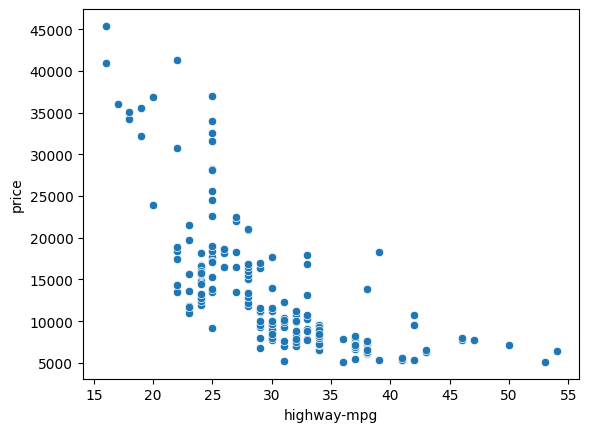

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x="highway-mpg", y="price")

(0.0, 48179.561473109636)

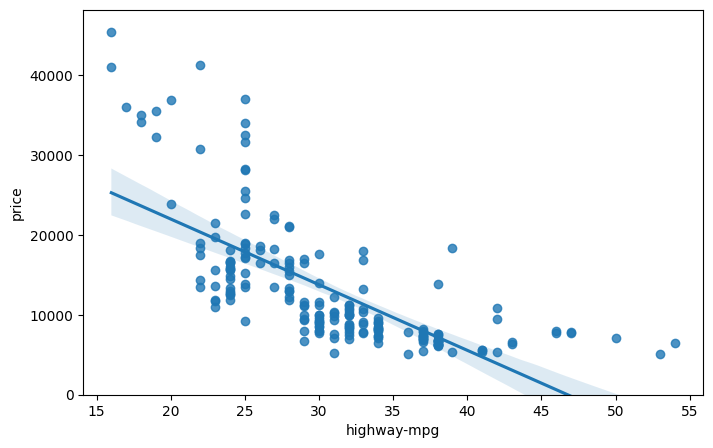

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

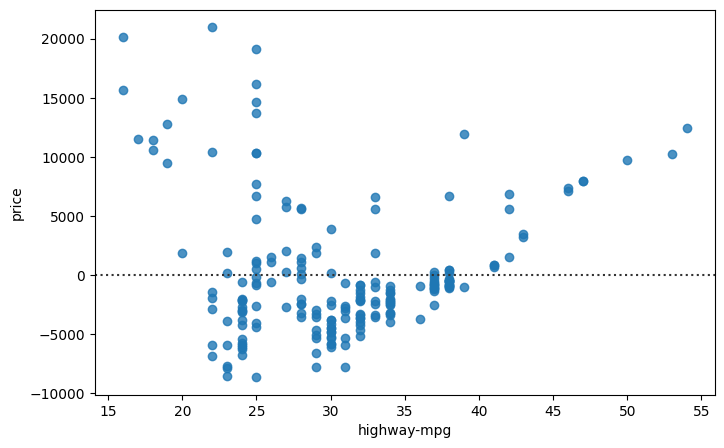

In [ ]:
plt.figure(figsize=(8,5))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

/tmp/ipykernel_7578/588266299.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/588266299.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values

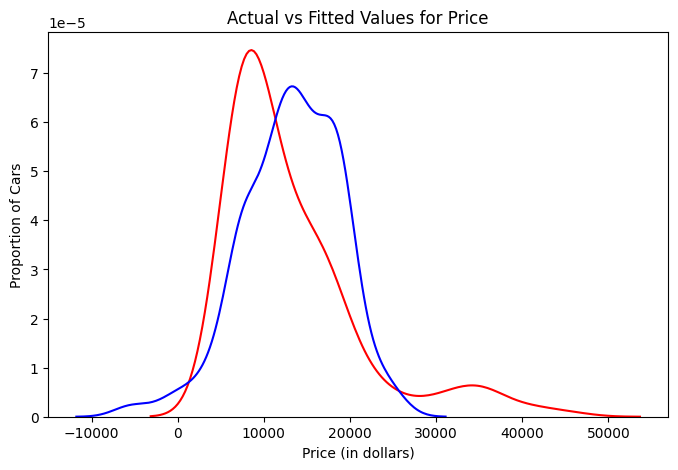

In [ ]:
Y_hat = lm.predict(X)

plt.figure(figsize=(8,5))
ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

Y_hat = lm.predict(X): Menggunakan model untuk memprediksi harga mobil (price) berdasarkan X. <br>
sns.distplot(...): Menampilkan distribusi nilai price aktual (df['price']) dengan garis merah dan nilai prediksi (Y_hat) dengan garis biru. <br>
Grafik ini membantu kita melihat sejauh mana prediksi model mendekati nilai price yang sebenarnya.

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(df[['highway-mpg']])
test_y = np.asanyarray(df[['price']])
test_y_ = lm.predict(df[['highway-mpg']])

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 7365.94
Residual sum of squares (MSE): 94048267.39
R2-score: -0.01


test_x: Merupakan array dari data highway-mpg sebagai variabel independen atau input untuk model prediksi. <br>
test_y: Merupakan array dari data price sebagai variabel target atau output yang sebenarnya (actual values). <br>
test_y_: Merupakan array dari hasil prediksi model (lm.predict) terhadap test_x. Ini berisi nilai harga mobil yang diprediksi oleh model berdasarkan highway-mpg <br> <br>

Menghitung Metrik Evaluasi <br>

*   MAE mengukur rata-rata nilai absolut dari selisih antara nilai prediksi dan nilai aktual.
*   MSE mengukur rata-rata dari kuadrat selisih antara nilai prediksi dan nilai aktual.
*   R2-score mengukur seberapa baik model mampu menjelaskan variabilitas dalam data target. <br> <br>

Jika hasilnya adalah: <br>
*   MAE tinggi berarti prediksi model kurang akurat.
*   MSE tinggi menandakan kesalahan kuadrat yang besar pada prediksi.
*   R2-score negatif atau mendekati 0 menunjukkan model tidak menjelaskan variabilitas data dengan baik, atau performa model tidak lebih baik dibandingkan dengan prediksi rata-rata. <br> <br>

Hasil: <br>
*   Mean Absolute Error: 7365.94, menunjukkan bahwa rata-rata kesalahan prediksi harga mobil adalah sekitar $7,365.94.
*   MSE: 94048267.39, menunjukkan besarnya kesalahan prediksi dalam satuan kuadrat.
*   R2-score: -0.01, menunjukkan bahwa model ini tidak berhasil memprediksi data dengan baik. Nilai R2 yang negatif berarti model regresi linear sederhana ini kurang cocok untuk data tersebut. Dalam kasus ini, skor negatif pada R2 mengindikasikan bahwa model ini mungkin kurang cocok untuk memprediksi harga mobil berdasarkan highway-mpg saja.

### Multiple Linear Regression

Pada bagian ini, kita membangun model Multiple Linear Regression (Regresi Linear Berganda) untuk memprediksi harga mobil (price) berdasarkan beberapa variabel independen: horsepower, curb-weight, engine-size, dan highway-mpg. Berikut adalah penjelasan rinci untuk setiap langkah, beserta hasil dan interpretasi dari metrik evaluasi.

In [ ]:
avg_horsepower = df['horsepower'].astype('float').mean() #Menghitung rata-rata horsepower pada dataset dan menyimpan hasilnya di variabel avg_horsepower
print("Average horsepower:", avg_horsepower)
df['horsepower'].replace(np.nan, avg_horsepower, inplace=True) #Jika terdapat nilai NaN pada kolom horsepower, nilai tersebut diganti dengan nilai rata-rata ini. Hal ini dilakukan untuk menjaga data tetap lengkap, sehingga tidak ada baris data yang dibuang karena nilai kosong.

Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']] #Z adalah variabel independen yang mencakup empat fitur: horsepower, curb-weight, engine-size, dan highway-mpg.
Y = df['price'] #Y adalah variabel dependen (target), yaitu price.

lm_mv = LinearRegression() #Model regresi linear berganda dilatih dengan memetakan Z ke Y menggunakan LinearRegression().
lm_mv.fit(Z,Y)
print('Dataset lengkap: ',df.shape)
print('Training data: ',X.shape)
print('Koefisien: ',lm_mv.coef_)
print('Intercept: ',lm_mv.intercept_)

Average horsepower: 103.39698492462311
Dataset lengkap:  (201, 26)
Training data:  (201, 1)
Koefisien:  [53.61042729  4.70886444 81.47225667 36.39637823]
Intercept:  -15824.03820823447


/tmp/ipykernel_7578/3551811811.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].replace(np.nan, avg_horsepower, inplace=True) #Jika terdapat nilai NaN pada kolom horsepower, nilai tersebut diganti dengan nilai rata-rata ini. Hal ini dilakukan untuk menjaga data tetap lengkap, sehingga tidak ada baris data yang dibuang karena nilai kosong.


Koefisien: [53.61, 4.71, 81.47, 36.40]
*   53.61 (koefisien horsepower): Setiap peningkatan 1 unit dalam horsepower diasosiasikan dengan kenaikan harga mobil sekitar $53.61.<br>
*   4.71 (koefisien curb-weight): Setiap kenaikan 1 unit pada curb-weight dikaitkan dengan peningkatan harga mobil sekitar $4.71. <br>
*   81.47 (koefisien engine-size): Setiap peningkatan 1 unit dalam engine-size diasosiasikan dengan kenaikan harga mobil sebesar $81.47. <br>
*   36.40 (koefisien highway-mpg): Setiap kenaikan 1 unit highway-mpg dikaitkan dengan kenaikan harga mobil sekitar $36.40. <br><br>

Intercept: -15824.04 <br>
Ini adalah harga dasar mobil ketika semua fitur bernilai 0, yang dalam konteks ini tidak selalu bermakna langsung, tetapi penting untuk perhitungan prediksi harga.

/tmp/ipykernel_7578/485738449.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/485738449.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_hat_mv, hist=False, color="b", label="Fitted Val

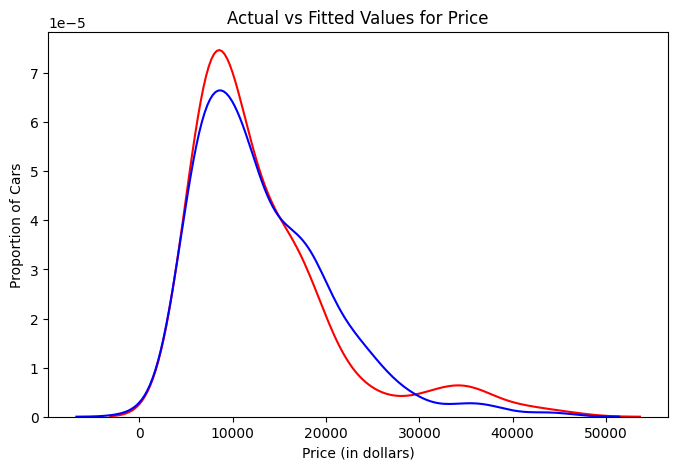

In [ ]:
Y_hat_mv = lm_mv.predict(Z)

plt.figure(figsize=(8,5))
ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat_mv, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

Plot ini membandingkan nilai aktual (price) dengan nilai prediksi (Y_hat_mv). <br>
Garis merah menunjukkan nilai harga aktual, sedangkan garis biru adalah nilai prediksi model. <br>
Jika kedua garis ini saling tumpang tindih atau dekat satu sama lain, itu menunjukkan bahwa model cukup baik dalam mendekati nilai aktual.

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(Z)
test_y = np.asanyarray(Y)
test_y_ = lm_mv.predict(Z)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 2450.43
Residual sum of squares (MSE): 11976801.68
R2-score: 0.76


Hasil:

Mean Absolute Error (MAE): 2450.43 <br>

MAE menunjukkan rata-rata kesalahan absolut antara prediksi dan nilai aktual, dalam satuan dolar. Nilai MAE sekitar 2450 menunjukkan bahwa model, rata-rata, memiliki kesalahan prediksi sebesar 2450.  <br> <br>

Mean Squared Error (MSE): 11976801.68  <br>
MSE adalah rata-rata dari kuadrat selisih antara nilai prediksi dan nilai aktual. MSE yang rendah menunjukkan bahwa model relatif akurat dalam memprediksi harga.  <br> <br>

R2-score: 0.76  <br>

R2-score (koefisien determinasi) mengukur seberapa baik model menjelaskan variabilitas data target (price). Nilai 0,76 berarti bahwa sekitar 76% dari variabilitas dalam price dapat dijelaskan oleh model ini. Semakin dekat ke 1, semakin baik model menjelaskan data. Nilai ini menunjukkan performa yang cukup baik untuk model regresi linear berganda ini.  <br>

### Polynomial Regression

Pada bagian ini, kita menggunakan Polynomial Regression (Regresi Polinomial) untuk memodelkan hubungan antara highway-mpg (konsumsi bahan bakar di jalan raya) dan price (harga mobil). Berbeda dengan regresi linear sederhana, regresi polinomial memungkinkan kita untuk menangkap hubungan non-linear antara variabel independen dan dependen.

In [ ]:
X = df['highway-mpg']
Y = df['price']

f = np.polyfit(X, Y, 3) #menghitung koefisien untuk polinomial derajat (degree) 3 yang paling sesuai antara highway-mpg dan price. (X, Y, degree)
p = np.poly1d(f) #membuat fungsi polinomial berdasarkan koefisien yang dihasilkan.
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


Hasil yang didapatkan adalah persamaan polinomial berikut:
−1.557𝑥^3+204.8𝑥^2−8965^𝑥+137900 <br>

Di sini,
x merepresentasikan variabel highway-mpg, yang merupakan konsumsi bahan bakar di jalan raya dan hasil dari persamaan ini adalah harga perkiraan mobil dalam dataset.



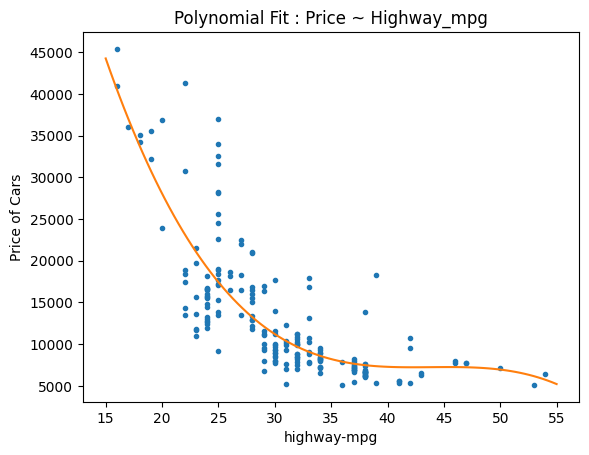

In [ ]:
def PlotPolly(model, independent_variable, dependent_variabble, Name): #memvisualisasikan kurva regresi polinomial di atas titik-titik data aktual.
    x_new = np.linspace(15, 55, 100) #Fungsi np.linspace() dari NumPy ini menghasilkan 100 nilai yang terdistribusi secara merata di antara angka 15 dan 55.
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit : Price ~ Highway_mpg')
    ax = plt.gca()
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

PlotPolly(p, X, Y, 'highway-mpg')

Fungsi PlotPolly memvisualisasikan kurva regresi polinomial di atas titik-titik data aktual. <br>
Kurva polinomial dihasilkan oleh y_new = model(x_new), yang menunjukkan hubungan antara highway-mpg dan price.<br>
Grafik ini membantu kita melihat bahwa model polinomial mampu mencocokkan data dengan lebih baik dibandingkan regresi linear, terutama jika data memiliki pola non-linear.<br>

/tmp/ipykernel_7578/3552476085.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/3552476085.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(p(X), hist=False, color="b", label="Fitted Value

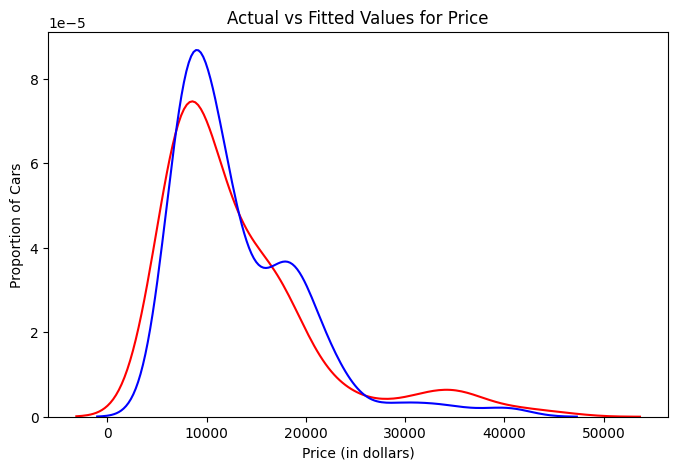

In [ ]:
plt.figure(figsize=(8, 5))

ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(p(X), hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(X)
test_y = np.asanyarray(Y)
test_y_ = p(X)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 2951.93
Residual sum of squares (MSE): 20474146.43
R2-score: 0.52


Hasil Evaluasi <br> <br>

Mean Absolute Error (MAE): 2951.93 <br>

Rata-rata kesalahan absolut antara nilai aktual dan prediksi adalah sekitar $2951.93. Angka ini lebih besar daripada regresi linear berganda, menunjukkan model ini memiliki kesalahan yang sedikit lebih besar. <br><br>

Mean squared error (MSE): 20474146.43 <br>

MSE ini lebih tinggi dibandingkan dengan regresi linear berganda, mengindikasikan bahwa model polinomial ini mungkin tidak seakurat model regresi berganda dalam memprediksi harga. <br><br>

R2-score: 0.52 <br>

R2-score sebesar 0,52 menunjukkan bahwa hanya 52% variabilitas dalam price yang dapat dijelaskan oleh highway-mpg melalui model polinomial ini. Nilai R2 ini lebih rendah dibandingkan dengan regresi linear berganda (0,76), mengindikasikan bahwa mungkin ada fitur-fitur lain yang lebih baik menjelaskan harga mobil daripada highway-mpg saja.

### Perbandingan Antar Model



1.   Regresi Linear (Linear Regression)
*    Model ini digunakan untuk memprediksi variabel dependen (Y) yang memiliki hubungan linear dengan satu variabel independen (X).
*    Hubungan antara variabel independen dan dependen adalah linier (garis lurus).

2.   Regresi Linear Berganda (Multiple Linear Regression)
*    Model ini digunakan ketika ada lebih dari satu variabel independen yang mempengaruhi variabel dependen. Ini cocok ketika hubungan antara variabel dependen dan independen lebih kompleks tetapi masih dapat dianggap linear.
*    Hubungan antara variabel dependen dan independen tetap linear meskipun ada beberapa variabel independen.
3.   Regresi Polinomial (Polynomial Regression)
*     Model ini digunakan untuk menangani hubungan yang non-linear antara variabel dependen dan independen. Regresi polinomial memperluas regresi linear dengan menambahkan istilah polinomial dari variabel independen.
*     Hubungan antara variabel dependen dan independen dapat berupa kurva (non-linear), tergantung pada derajat polinomial yang digunakan.



# Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
df_train = pd.read_csv('Datasets/train_energy_data.csv')

## Data Understanding

### Dataset Description

In [4]:
df_train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


- Variabel dependen (target):
  - Energy Consumption

- Variabel independen (fitur):
  - Building Type
  - Square Footage
  - Number of Occupants
  - Appliances Used
  - Average Temperature
  - Day of Week

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


Dataset terdiri dari:
- Variabel numerikal: Square Footage, Number of Occupants, Appliances Used, Average Temperature, Energy Consumption
- Variabel kategorikal: Building Type, Day of Week

### Check Missing Values

In [6]:
df_train.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

### Check Duplicates

In [7]:
df_train.duplicated().sum()

np.int64(0)

### Descriptive Statistics

In [8]:
df_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


Berdasarkan hasil statistik deskriptif, diperoleh informasi sebagai berikut:

- **Square Footage** memiliki rata-rata sekitar 25,462 dengan nilai minimum 560 dan maksimum 49,997. Hal ini menunjukkan variasi luas bangunan yang cukup besar dalam dataset.

- **Number of Occupants** memiliki rata-rata sekitar 48 orang dengan rentang antara 1 hingga 99. Distribusi ini menunjukkan variasi jumlah penghuni yang cukup merata.

- **Appliances Used** memiliki rata-rata sekitar 25 perangkat dengan nilai minimum 1 dan maksimum 49 yang menunjukkan variasi penggunaan perangkat listrik dalam bangunan.

- **Average Temperature** memiliki rata-rata sekitar 22.61°C dengan rentang dari 10.05°C hingga 34.99°C yang menunjukkan suhu lingkungan dalam rentang yang masih realistis.

- **Energy Consumption** sebagai variabel target memiliki rata-rata sekitar 4166 dengan nilai minimum 1683 dan maksimum 6530. Hal ini menunjukkan variasi konsumsi energi yang cukup besar dalam dataset.

Berdasarkan statistik deskriptif, terlihat bahwa nilai mean dan median memiliki jarak yang dekat sehingga sebagian besar variabel memiliki distribusi yang relatif simetris. Namun, terdapat kemungkinan adanya variasi data yang cukup tinggi pada kolom Square Footage dan Energy Consumption yang ditunjukkan oleh nilai standar deviasi yang besar. Selain itu, tidak ditemukan indikasi nilai yang tidak logis (anomali) pada seluruh variabel numerik.

### Data Distribution Analysis

array([[<Axes: title={'center': 'Square Footage'}>,
        <Axes: title={'center': 'Number of Occupants'}>],
       [<Axes: title={'center': 'Appliances Used'}>,
        <Axes: title={'center': 'Average Temperature'}>],
       [<Axes: title={'center': 'Energy Consumption'}>, <Axes: >]],
      dtype=object)

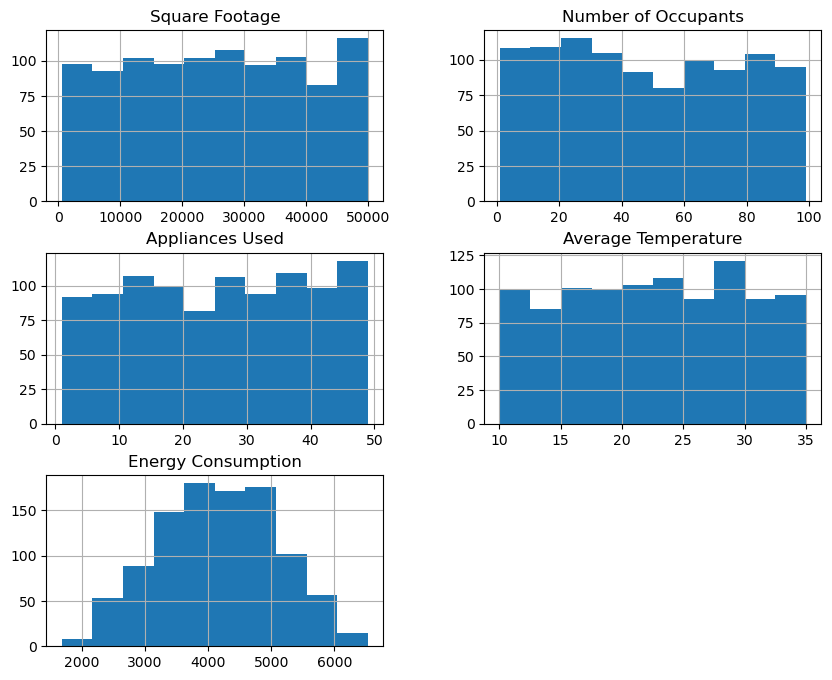

In [9]:
df_train.hist(figsize=(10,8))

Sebagian besar fitur numerik memiliki distribusi yang relatif merata tanpa skew yang signifikan. Variabel Energy Consumption menunjukkan pola mendekati distribusi normal.

### Identify Outliers

<Axes: >

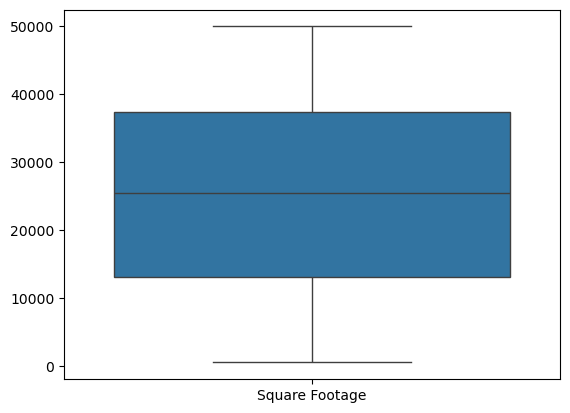

In [10]:
sns.boxplot(data=df_train[['Square Footage']])

<Axes: >

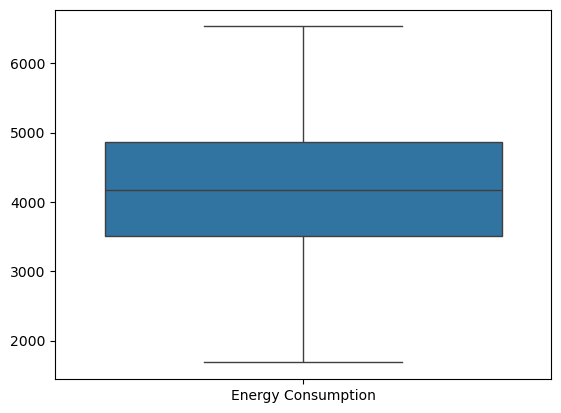

In [11]:
sns.boxplot(data=df_train[['Energy Consumption']])

Identifikasi outlier hanya dilakukan pada variabel Square Footage dan Energy Consumption (variabel lain sudah terlihat jelas tidak memiliki outlier melalui statistik deskriptif sebelumnya). Boxplot di atas tidak menunjukkan adanya outlier pada dua variabel tersebut.

### Trend Analysis and Visualization

In [12]:
df_train.corr(numeric_only=True)

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


Berdasarkan hasil analisis korelasi, Square Footage merupakan fitur yang paling berpengaruh terhadap Energy Consumption sehingga menjadi kandidat fitur utama yang digunakan dalam pemodelan regresi linear. Sementara itu, fitur lain seperti Number of Occupants dan Appliances Used tetap dipertimbangkan karena memberikan kontribusi tambahan terhadap variasi konsumsi energi.

<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

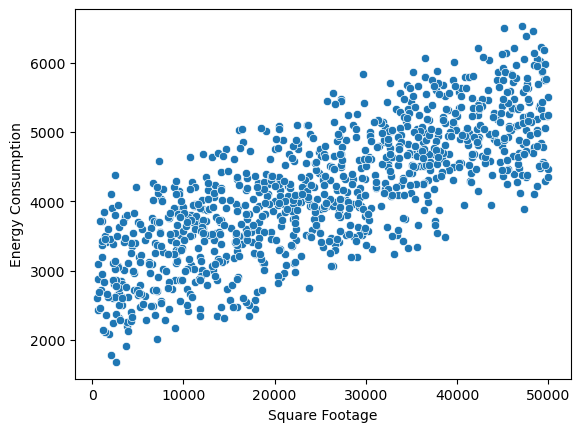

In [13]:
sns.scatterplot(x='Square Footage', y='Energy Consumption', data=df_train)

Visualisasi menunjukkan kecenderungan peningkatan konsumsi energi seiring bertambahnya luas bangunan.

### Categorical Variable Analysis

In [14]:
df_train['Building Type'].value_counts()

Building Type
Residential    347
Commercial     336
Industrial     317
Name: count, dtype: int64

In [15]:
df_train['Day of Week'].value_counts()

Day of Week
Weekday    507
Weekend    493
Name: count, dtype: int64

Berdasarkan distribusi variabel kategorikal, diperoleh informasi sebagai berikut:

- **Building Type** terdiri dari tiga kategori, yaitu Residential (347 data), Commercial (336 data), dan Industrial (317 data). Distribusi ini relatif seimbang antar kategori sehingga tidak terdapat dominasi yang signifikan dari salah satu tipe bangunan.

- **Day of Week** terbagi menjadi Weekday (507 data) dan Weekend (493 data). Distribusi ini juga menunjukkan keseimbangan yang baik antara kedua kategori.

Keseimbangan distribusi pada variabel kategorikal dapat mengurangi potensi bias dalam model dan memastikan bahwa setiap kategori dapat direpresentasikan dengan baik saat training model. Karena kedua variabel bersifat kategorikal, diperlukan proses encoding (seperti one-hot encoding) sebelum digunakan dalam model regresi.

### Feature Selection and Justification

Pemilihan fitur dilakukan berdasarkan hasil analisis korelasi, distribusi data, serta relevansi secara domain terhadap variabel dependen (Energy Consumption).

Pada model linear regression biasa, digunakan satu variabel independen yaitu **Square Footage**. Fitur ini dipilih karena memiliki nilai korelasi tertinggi terhadap Energy Consumption (0.77) yang menunjukkan hubungan linear yang kuat sehingga paling berpengaruh dalam prediksi.

Pada model multiple linear regression, seluruh fitur digunakan karena masing-masing variabel memiliki kontribusi baik secara statistik maupun secara logika terhadap Energy Consumption.

Pada model polynomial regression, fitur utama yaitu Square Footage ditransformasikan ke dalam bentuk polinomial untuk menangkap kemungkinan hubungan non-linear antara variabel independen dan dependen.

## Preprocessing Data

### One-hot Encoding

In [16]:
df_train = pd.get_dummies(df_train, drop_first=True).astype(int)
df_train.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29,2713,0,1,0
1,44372,66,45,16,5744,0,0,0
2,19255,37,17,14,4101,1,0,1
3,13265,14,41,32,3009,0,1,0
4,13375,26,18,11,3279,0,0,0


### Seperate Independent and Dependent Variable

In [17]:
X = df_train.drop('Energy Consumption', axis=1)
y = df_train['Energy Consumption']

### Feature Scaling

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train-test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Regresi Linear

## Multiple Linear Regression

Model Multiple Linear Regression (MLR) dibangun menggunakan semua fitur yang telah melalui proses preprocessing — termasuk one-hot encoding dan feature scaling. Seluruh fitur independen yang tersedia digunakan karena masing-masing memiliki kontribusi yang relevan terhadap prediksi Energy Consumption, baik secara statistik maupun secara domain.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lm_mv = LinearRegression()
lm_mv.fit(X_train, y_train)

feature_names = df_train.drop('Energy Consumption', axis=1).columns
print('Koefisien:')
for name, coef in zip(feature_names, lm_mv.coef_):
    print(f'  {name}: {coef:.4f}')
print(f'Intercept: {lm_mv.intercept_:.4f}')

Koefisien:
  Square Footage: 714.4469
  Number of Occupants: 290.5408
  Appliances Used: 281.9726
  Average Temperature: -35.6468
  Building Type_Industrial: 232.5786
  Building Type_Residential: -238.0460
  Day of Week_Weekend: -24.9782
Intercept: 4165.7274


Koefisien yang dihasilkan mencerminkan pengaruh masing-masing fitur terhadap Energy Consumption dalam satuan yang telah distandarisasi:

- **Square Footage** memiliki koefisien terbesar (~714.45), menunjukkan pengaruh paling dominan. Semakin luas bangunan, semakin besar konsumsi energinya.
- **Number of Occupants** (~290.54) dan **Appliances Used** (~281.97) juga berpengaruh signifikan dan positif — lebih banyak penghuni dan perangkat berarti lebih besar konsumsi energi.
- **Average Temperature** memiliki koefisien negatif kecil (~-35.65), mengindikasikan pada suhu lebih tinggi penggunaan pemanas berkurang.
- **Building Type_Industrial** (~232.58) menunjukkan konsumsi lebih tinggi dibanding Commercial (referensi), sedangkan **Building Type_Residential** (~-238.05) lebih rendah.
- **Day of Week_Weekend** (~-24.98) menunjukkan konsumsi sedikit lebih rendah di akhir pekan, yang masuk akal karena aktivitas bisnis dan industri berkurang.

In [21]:
y_pred_mv = lm_mv.predict(X_test)

mae_mv = mean_absolute_error(y_test, y_pred_mv)
mse_mv = mean_squared_error(y_test, y_pred_mv)
r2_mv = r2_score(y_test, y_pred_mv)

print(f'Mean Absolute Error (MAE) : {mae_mv:.2f}')
print(f'Mean Squared Error (MSE)  : {mse_mv:.2f}')
print(f'R2-score                  : {r2_mv:.4f}')

Mean Absolute Error (MAE) : 1.29
Mean Squared Error (MSE)  : 2.27
R2-score                  : 1.0000


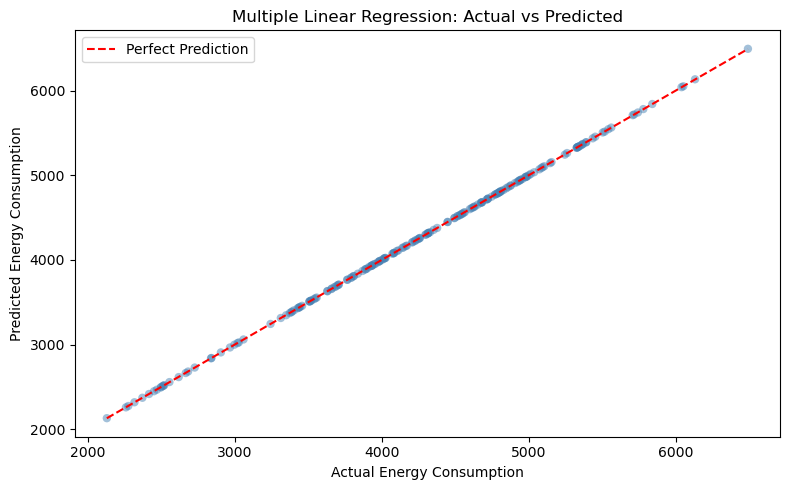

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_mv, alpha=0.5, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

**Evaluasi Model Multiple Linear Regression:**

- **MAE ≈ 1.29** — Rata-rata selisih antara prediksi dan nilai aktual hanya sekitar 1.29 unit, sangat kecil dibanding rata-rata Energy Consumption (~4166).
- **MSE ≈ 2.27** — Nilai MSE yang sangat rendah mengonfirmasi tidak ada kesalahan besar dalam model.
- **R²-score ≈ 1.0000** — Model mampu menjelaskan hampir 100% variasi dalam data konsumsi energi, mengindikasikan seluruh fitur memiliki hubungan linear yang sangat kuat dengan variabel target.

Scatter plot memperlihatkan titik-titik data yang berkumpul rapat di sekitar garis merah (garis prediksi sempurna), mengonfirmasi performa model yang sangat baik.

## Polynomial Regression

Polynomial Regression digunakan untuk menangkap kemungkinan hubungan non-linear antara fitur-fitur independen dan Energy Consumption. Digunakan `PolynomialFeatures` dengan derajat 2, yang menghasilkan fitur-fitur baru berupa kombinasi kuadrat dan interaksi antar fitur. Derajat 2 dipilih sebagai keseimbangan antara kompleksitas model dan risiko overfitting.

In [23]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lm_poly = LinearRegression()
lm_poly.fit(X_train_poly, y_train)

print(f'Jumlah fitur asli   : {X_train.shape[1]}')
print(f'Jumlah fitur poly   : {X_train_poly.shape[1]}')
print(f'Intercept           : {lm_poly.intercept_:.4f}')

Jumlah fitur asli   : 7
Jumlah fitur poly   : 36
Intercept           : 4160.5748


In [24]:
y_pred_poly = lm_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Mean Absolute Error (MAE) : {mae_poly:.2f}')
print(f'Mean Squared Error (MSE)  : {mse_poly:.2f}')
print(f'R2-score                  : {r2_poly:.4f}')

Mean Absolute Error (MAE) : 1.30
Mean Squared Error (MSE)  : 2.32
R2-score                  : 1.0000


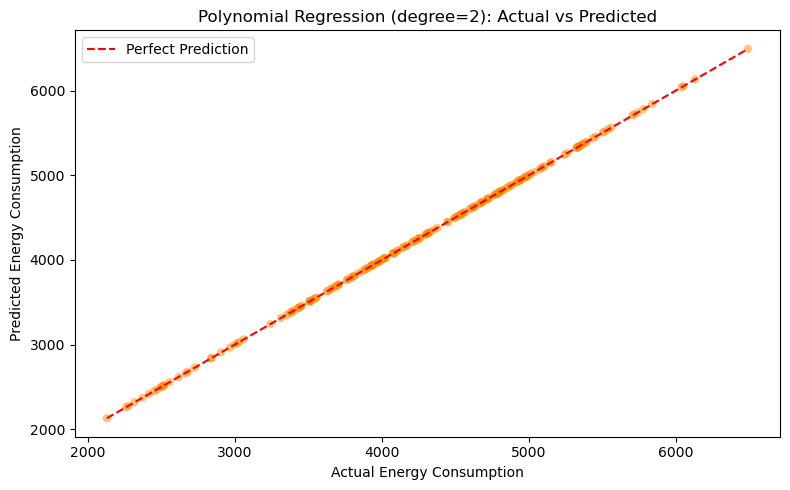

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_poly, alpha=0.5, color='darkorange', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Polynomial Regression (degree=2): Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

**Evaluasi Model Polynomial Regression (degree=2):**

- **MAE ≈ 1.30** — Sangat mirip dengan MLR; penambahan fitur polinomial tidak memberikan peningkatan akurasi yang berarti.
- **MSE ≈ 2.32** — Sedikit lebih tinggi dari MLR, menunjukkan fitur interaksi kuadrat tidak banyak mengurangi kesalahan residual.
- **R²-score ≈ 1.0000** — Sama seperti MLR, model polinomial juga mampu menjelaskan hampir seluruh variasi dalam data.

Hasil ini menunjukkan bahwa hubungan antara fitur-fitur dan Energy Consumption pada dataset ini sudah bersifat hampir linear. Transformasi polinomial tidak memberikan keuntungan bermakna, bahkan menambah kompleksitas secara signifikan (dari 7 menjadi 36 fitur).

## Perbandingan Antar Model

In [26]:
models_name = ['Multiple Linear Regression', 'Polynomial Regression (degree=2)']
maes = [mae_mv, mae_poly]
mses = [mse_mv, mse_poly]
r2s  = [r2_mv, r2_poly]

print(f'{"Model":<35} {"MAE":>8} {"MSE":>10} {"R2":>8}')
print('-' * 65)
for m, mae, mse, r2 in zip(models_name, maes, mses, r2s):
    print(f'{m:<35} {mae:>8.2f} {mse:>10.2f} {r2:>8.4f}')

Model                                    MAE        MSE       R2
-----------------------------------------------------------------
Multiple Linear Regression              1.29       2.27   1.0000
Polynomial Regression (degree=2)        1.30       2.32   1.0000


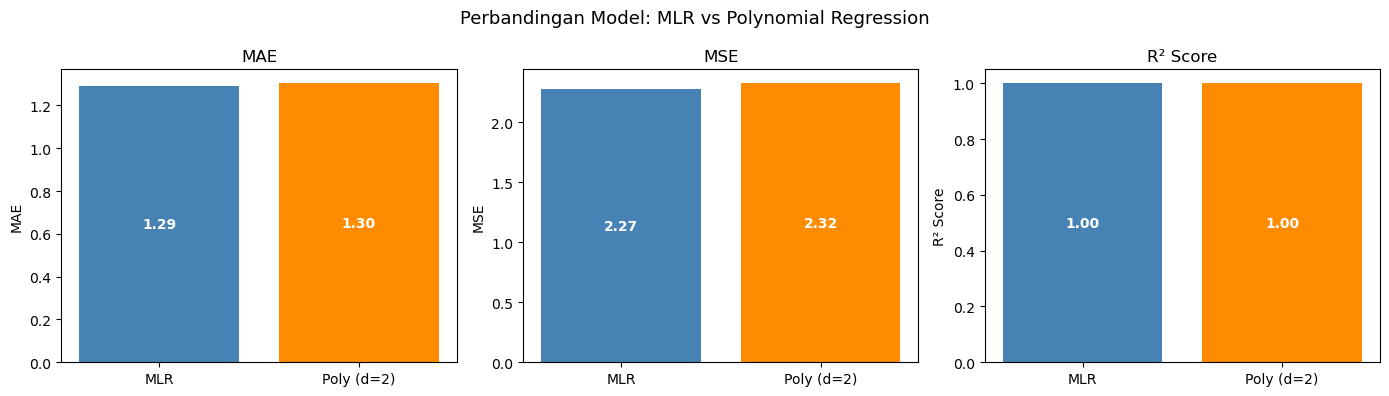

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = {'MAE': maes, 'MSE': mses, 'R² Score': r2s}
colors = ['steelblue', 'darkorange']
short_labels = ['MLR', 'Poly (d=2)']

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(short_labels, values, color=colors)
    ax.set_title(metric_name)
    ax.set_ylabel(metric_name)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                f'{val:.2f}', ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Perbandingan Model: MLR vs Polynomial Regression', fontsize=13)
plt.tight_layout()
plt.show()

**Perbandingan Multiple Linear Regression vs Polynomial Regression:**

| Metrik | Multiple Linear Regression | Polynomial Regression (d=2) |
|--------|---------------------------|-----------------------------|
| MAE    | ~1.29                     | ~1.30                       |
| MSE    | ~2.27                     | ~2.32                       |
| R²     | ~1.0000                   | ~1.0000                     |

**Kesimpulan:**

- **Multiple Linear Regression sedikit lebih unggul** pada semua metrik (MAE dan MSE lebih rendah), meski perbedaannya tidak signifikan secara praktis.
- Polynomial Regression meningkatkan kompleksitas model secara drastis tanpa peningkatan performa yang sepadan.
- Hal ini mengindikasikan bahwa hubungan antara fitur-fitur independen dan Energy Consumption pada dataset ini memang bersifat linear.

**Rekomendasi untuk pengambilan keputusan bisnis:**

Berdasarkan hasil pemodelan, Multiple Linear Regression sudah cukup untuk memprediksi konsumsi energi dengan sangat akurat. Model ini dapat dimanfaatkan sebagai sistem rekomendasi untuk:
1. **Efisiensi energi**: Mengidentifikasi bangunan dengan prediksi konsumsi tinggi (berdasarkan luas, jumlah penghuni, dan tipe bangunan) sebagai prioritas intervensi penghematan energi.
2. **Perencanaan kapasitas**: Memberikan estimasi kebutuhan energi bangunan baru sebelum dibangun, membantu pengambilan keputusan terkait instalasi listrik dan sistem pemanas/pendingin.
3. **Benchmark performa**: Membandingkan konsumsi energi aktual dengan prediksi model — jika konsumsi aktual jauh di atas prediksi, ini bisa menjadi sinyal adanya pemborosan atau kerusakan peralatan.